<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini-Proyecto 3: Clasificación de Texto con Transformers
## Corpus: Resúmenes de Artículos Científicos (arXiv)

---

### Contexto del proyecto
Este proyecto es la continuación directa del Mini-Proyecto 2. Habiendo explorado Random Forest, Embeddings y LSTM sobre el mismo corpus de arXiv, implementamos ahora la arquitectura que revolucionó el NLP desde 2017: los **Transformers** (paper: *"Attention is All You Need"*, Vaswani et al.).

A diferencia del proyecto anterior donde usamos **TensorFlow/Keras**, aquí trabajamos con **PyTorch y PyTorch Lightning**, el stack estándar de la industria para investigación en Deep Learning. Construimos el Transformer **desde sus componentes fundamentales**: Positional Encodings, Multi-Head Attention y TransformerBlock, para entender exactamente cómo funciona por dentro antes de usarlo como caja negra.

**Pregunta central:** ¿Puede un Transformer entrenado desde cero superar a los modelos del Proyecto 2 sobre el mismo corpus científico de arXiv?

---

## Herramientas utilizadas

* **PyTorch** para la construcción de los módulos de la arquitectura Transformer desde cero (`nn.Module`), con control explícito sobre cada operación matricial del mecanismo de atención.

* **PyTorch Lightning** como framework de entrenamiento de alto nivel, equivalente al `.fit()` de Keras pero con mayor flexibilidad para investigación.

* **HuggingFace Transformers** para el tokenizador `bert-base-uncased`, que utiliza BPE (Byte Pair Encoding) para manejar vocabulario técnico científico de forma más robusta que un tokenizador simple por palabras.

* **Scikit-Learn** para la codificación de etiquetas (`LabelEncoder`), el split estratificado y el cálculo de `class_weights` para el manejo del desbalance de clases.

* **NLTK y Regex** para la limpieza especializada de abstracts, con filtros específicos para comandos LaTeX y fórmulas matemáticas, reutilizados directamente del Proyecto 2.

* **Matplotlib y Seaborn** para la visualización de Positional Encodings, curvas de entrenamiento y la matriz de confusión final.

## Paso 1 — Instalación de dependencias y reproducibilidad
Google Colab ya incluye PyTorch con soporte GPU. Instalamos únicamente los paquetes que no vienen por defecto.

Adicionalmente, fijamos una **semilla aleatoria global** (`seed=42`) para garantizar la reproducibilidad de los resultados. Sin esto, cada ejecución produce un accuracy ligeramente diferente debido a tres fuentes de aleatoriedad:

* La **inicialización aleatoria de los 4.1M parámetros** del modelo al instanciarlo.
* El **shuffle del DataLoader**, que cambia el orden en que el modelo ve los batches cada época.
* El **Dropout**, que apaga neuronas al azar durante el entrenamiento.

Fijar la semilla elimina estas variaciones y hace que los resultados sean comparables y auditables.

In [1]:
# Instalamos solo lo que Colab no trae por defecto
!pip install -q lightning==2.2.0 'transformers[torch]'==4.41.2 torchmetrics datasets

import warnings
warnings.filterwarnings('ignore')

# ==========================================
# SEMILLA GLOBAL — Reproducibilidad
# ==========================================
import random
import numpy as np
import torch

def set_seed(seed: int = 42):
    """Fija todas las semillas para garantizar resultados reproducibles."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Hace que las operaciones de CUDA sean deterministas
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f'Semilla fijada: {seed}')

set_seed(42)
print('Instalación completa')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 36.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==

## Paso 2 — Importación de librerías y configuración del entorno
Para el desarrollo de este proyecto se configuró un entorno que integra el ecosistema de **PyTorch** para Deep Learning y **HuggingFace** para el procesamiento de texto. Se utiliza **NLTK** para la limpieza de stopwords, **Pandas y NumPy** para la manipulación del dataset de arXiv, y **Scikit-Learn** para el preprocesamiento de etiquetas y el manejo del desbalance de clases. La arquitectura Transformer completa se construye con **PyTorch puro**, mientras que **PyTorch Lightning** gestiona el loop de entrenamiento. La verificación del dispositivo disponible (CPU vs GPU) se realiza al final para confirmar que el entrenamiento aprovechará la aceleración por hardware.

In [2]:
# --- Librerías base ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import requests
import xml.etree.ElementTree as ET
from tqdm.auto import tqdm

# --- NLP ---
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# --- Machine Learning ---
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

# --- PyTorch Lightning ---
from lightning import LightningModule, Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from torchmetrics import Accuracy

# --- HuggingFace Tokenizer ---
from transformers import AutoTokenizer

# --- Visualización ---
from wordcloud import WordCloud

# Verificamos que la GPU está disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Librerías cargadas')
print(f'Dispositivo disponible: {device.upper()}')
if device == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

Librerías cargadas
Dispositivo disponible: CUDA
   GPU: Tesla T4


## Paso 3 — Carga y Estructura del Dataset
El dataset se genera mediante harvesting desde la API OAI-PMH de arXiv (20,000 registros desde 2022), reutilizando exactamente el mismo pipeline de extracción del Proyecto 2. Esto garantiza que cualquier diferencia en los resultados finales se deba exclusivamente a la arquitectura del modelo y no a variaciones en los datos.

**Columnas relevantes para el análisis:**

* `abstract`: Texto libre del resumen científico — variable independiente (X).
* `primary_category`: Etiqueta temática asignada por el autor — variable objetivo (y).
* `title`: Título del artículo — contexto adicional no utilizado en el modelo.

Los abstracts presentan los mismos desafíos identificados en el Proyecto 2: sintaxis LaTeX, fórmulas matemáticas y terminología técnica densa que requiere limpieza especializada antes del modelado.

> 💡 **Tip de eficiencia**: Si ya ejecutaste el Proyecto 2, guarda el DataFrame con `df_arxiv.to_csv('arxiv_dataset.csv', index=False)` y cárgalo aquí con la Opción A para evitar la descarga (~20 minutos).

In [23]:
OAI_ENDPOINT = 'http://export.arxiv.org/oai2'
METADATA_PREFIX = 'arXiv'
MAX_RECORDS = 20000
BATCH_SIZE = 200
FROM_DATE = '2022-01-01'
SLEEP_BETWEEN = 1.0

ns = {
    'oai': 'http://www.openarchives.org/OAI/2.0/',
    'arxiv': 'http://arxiv.org/OAI/arXiv/'
}

def build_params(verb='ListRecords', metadataPrefix=METADATA_PREFIX,
                 resumptionToken=None, from_date=None):
    params = {'verb': verb}
    if resumptionToken:
        params['resumptionToken'] = resumptionToken
    else:
        params['metadataPrefix'] = metadataPrefix
        if from_date:
            params['from'] = from_date
    return params

def parse_records(xml_text):
    root = ET.fromstring(xml_text)
    records = []
    for record in root.findall('.//oai:record', ns):
        try:
            meta = record.find('oai:metadata/arxiv:arXiv', ns)
            if meta is None:
                continue
            abstract = meta.findtext('arxiv:abstract', default='', namespaces=ns).strip()
            title    = meta.findtext('arxiv:title',    default='', namespaces=ns).strip()
            cats     = meta.findtext('arxiv:categories', default='', namespaces=ns).strip()
            primary  = cats.split()[0] if cats else ''
            if abstract and primary:
                records.append({'title': title, 'abstract': abstract,
                                'primary_category': primary})
        except Exception:
            continue
    token_el = root.find('.//oai:resumptionToken', ns)
    token = token_el.text if token_el is not None else None
    return records, token

def fetch_arxiv_dataset(max_records=MAX_RECORDS, from_date=FROM_DATE):
    all_records = []
    token = None
    pbar = tqdm(total=max_records, desc='Descargando arXiv')
    while len(all_records) < max_records:
        params = build_params(resumptionToken=token, from_date=from_date)
        response = requests.get(OAI_ENDPOINT, params=params, timeout=60)
        if response.status_code != 200:
            break
        records, token = parse_records(response.text)
        all_records.extend(records)
        pbar.update(len(records))
        if not token:
            break
        time.sleep(SLEEP_BETWEEN)
    pbar.close()
    return pd.DataFrame(all_records[:max_records])

print('Listo para extraer.')

Listo para extraer.


In [4]:
df_arxiv = fetch_arxiv_dataset()
print(f'Dataset descargado: {df_arxiv.shape[0]} registros')
df_arxiv.head(3)

Descargando arXiv:   0%|          | 0/20000 [00:00<?, ?it/s]

Dataset descargado: 20000 registros


,title,abstract,primary_category
0,Global stabilization of multiple integrators b...,"In this paper, we address the global stabiliza...",eess.SY
1,When deep learning models on GPU can be accele...,This paper is focused on the improvement the e...,cs.LG
2,Cross-Validation and Uncertainty Determination...,Randomized artificial neural networks such as ...,stat.ML


## Paso 4 — Preprocesamiento de Texto
En esta etapa reutilizamos íntegramente el pipeline de limpieza del Proyecto 2, lo que nos permite hacer una comparación justa entre arquitecturas sobre exactamente el mismo corpus procesado.

**Acciones realizadas:**

* **Limpieza especializada**: Se eliminan comandos LaTeX (`\comando`) y fórmulas matemáticas delimitadas por `$...$`, que representan ruido sin valor semántico para el clasificador. Se filtran stopwords del inglés y tokens de menos de 3 caracteres.

* **Filtro Top 10 categorías**: De las 153 categorías únicas del dataset, seleccionamos las 10 más frecuentes para garantizar representatividad estadística y comparabilidad con el Proyecto 2.

* **Codificación de etiquetas**: Las categorías de texto (ej: `cs.LG`) se transforman a índices numéricos con `LabelEncoder` de Scikit-Learn.

* **Split estratificado 80/20**: La división entrenamiento/prueba mantiene la proporción de cada categoría en ambos conjuntos, con `random_state=42` para reproducibilidad.

In [5]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Limpieza especializada para abstracts científicos de arXiv."""
    text = text.lower()
    # Eliminar comandos LaTeX y fórmulas matemáticas
    text = re.sub(r'\$.*?\$', '', text)
    text = re.sub(r'\\(\w+)', '', text)
    # Conservar únicamente letras
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokenizer_re = RegexpTokenizer(r'\w+')
    tokens = tokenizer_re.tokenize(text)
    filtered = [w for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(filtered)

# Filtrar Top 10 categorías
category_counts = df_arxiv['primary_category'].value_counts()
top_10 = category_counts.head(10).index
df_filtered = df_arxiv[df_arxiv['primary_category'].isin(top_10)].copy()

# Limpiar textos
print('Limpiando abstracts...')
df_filtered['cleaned_text'] = df_filtered['abstract'].apply(clean_text)

# Codificar etiquetas
le = LabelEncoder()
df_filtered['label'] = le.fit_transform(df_filtered['primary_category'])
num_classes = len(le.classes_)

print(f'Dataset listo: {df_filtered.shape[0]} registros | {num_classes} categorías')
print(f'Categorías: {list(le.classes_)}')

Limpiando abstracts...
Dataset listo: 6544 registros | 10 categorías
Categorías: ['astro-ph.GA', 'cond-mat.mtrl-sci', 'cs.CL', 'cs.CV', 'cs.LG', 'hep-ph', 'hep-th', 'math.AP', 'math.CO', 'quant-ph']


In [6]:
# Split 80/20 estratificado (mismo que proyecto anterior)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df_filtered['cleaned_text'].values,
    df_filtered['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df_filtered['label']
)

print(f'Train: {len(X_train_text)} | Test: {len(X_test_text)}')

Train: 5235 | Test: 1309


## Paso 5 — Tokenizador HuggingFace (BERT)
En el Proyecto 2 utilizamos el `Tokenizer` de Keras, que asigna un índice único a cada palabra completa del vocabulario. Para este proyecto adoptamos el tokenizador de `bert-base-uncased`, que implementa **BPE (Byte Pair Encoding)**: en lugar de palabras enteras, divide el texto en sub-palabras frecuentes.

Esta diferencia es crítica para textos científicos. Con el tokenizador de Keras, términos como *"astrophysical"* y *"astrophysics"* se trataban como tokens completamente distintos. Con BPE, ambos comparten el sub-token `"astro"`, permitiendo al modelo aprender que ambas palabras pertenecen al dominio de la astronomía independientemente del sufijo.

El vocabulario de `bert-base-uncased` (30,522 tokens) fue preentrenado sobre Wikipedia y BookCorpus en inglés, cubriendo de forma natural gran parte del vocabulario técnico-científico de arXiv.

In [7]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# Cargamos el tokenizador de BERT (preentrenado en inglés)
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# Exploramos cómo tokeniza vocabulario científico
ejemplo = 'astrophysical observations using quantum entanglement'
tokens = tokenizer.tokenize(ejemplo)
print(f'Texto original: "{ejemplo}"')
print(f'Tokens: {tokens}')
print(f'IDs:    {tokenizer.encode(ejemplo)}')
print(f'\nVocabulario total: {tokenizer.vocab_size} tokens')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Texto original: "astrophysical observations using quantum entanglement"
Tokens: ['astro', '##physical', 'observations', 'using', 'quantum', 'en', '##tangle', '##ment']
IDs:    [101, 28625, 23302, 9420, 2478, 8559, 4372, 23395, 3672, 102]

Vocabulario total: 30522 tokens


## Paso 6 — Dataset y DataLoaders de PyTorch
En Keras, el preprocesamiento y la carga de datos se gestionaban de forma implícita al pasar arrays directamente a `.fit()`. En PyTorch este proceso es explícito y se divide en dos componentes:

* **`Dataset`**: Clase que define cómo acceder a un único ejemplo del corpus. Implementa `__getitem__` para tokenizar el texto on-the-fly y `__len__` para informar el tamaño total.

* **`DataLoader`**: Envuelve el Dataset y gestiona automáticamente el agrupamiento en batches, el shuffle por época y la carga en paralelo con múltiples workers.

**¿Qué es la `attention_mask`?**
Al aplicar padding para igualar la longitud de todas las secuencias, queremos que el modelo ignore los tokens de relleno. La `attention_mask` es un vector binario donde `1` indica token real y `0` indica padding. El mecanismo de Multi-Head Attention utiliza esta máscara para asignar peso `-inf` a las posiciones de padding antes del softmax, haciendo que su contribución sea efectivamente cero.

In [8]:
MAX_SEQUENCE_LENGTH = 256  # Abstracts de arXiv son ~150-200 palabras; 256 tokens es suficiente

class ArxivDataset(Dataset):
    """Dataset de abstracts científicos de arXiv para clasificación con Transformers."""

    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Tokenizamos: truncamos si es muy largo, padding si es muy corto
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'  # Devuelve tensores de PyTorch directamente
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),       # shape: (max_len,)
            'attention_mask': encoding['attention_mask'].squeeze(0),  # shape: (max_len,)
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Creamos los datasets
train_dataset = ArxivDataset(X_train_text, y_train, tokenizer, MAX_SEQUENCE_LENGTH)
test_dataset  = ArxivDataset(X_test_text,  y_test,  tokenizer, MAX_SEQUENCE_LENGTH)

# Verificamos un elemento
sample = train_dataset[0]
print(f'input_ids shape:      {sample["input_ids"].shape}')
print(f'attention_mask shape: {sample["attention_mask"].shape}')
print(f'label:                {sample["label"]} ({le.inverse_transform([sample["label"].item()])[0]})')

input_ids shape:      torch.Size([256])
attention_mask shape: torch.Size([256])
label:                5 (hep-ph)


In [9]:
BATCH_SIZE_DL = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_DL, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE_DL, shuffle=False, num_workers=2)

print(f'DataLoaders listos')
print(f'Batches de entrenamiento: {len(train_loader)}')
print(f'Batches de prueba:        {len(test_loader)}')

DataLoaders listos
Batches de entrenamiento: 164
Batches de prueba:        41


## Paso 7 — Positional Encodings
Las **LSTMs** procesan el texto palabra por palabra, en orden secuencial. El orden temporal está implícito en la arquitectura: la palabra en el paso `t` siempre llega después de la del paso `t-1`.

Los **Transformers** procesan todas las palabras simultáneamente en paralelo, lo que los hace significativamente más rápidos con GPU. Sin embargo, al no existir un orden de procesamiento, el modelo pierde la noción de posición: las frases *"el modelo no es bueno"* y *"el modelo es no bueno"* serían indistinguibles.

La solución propuesta en el paper original es inyectar información posicional **sumando un vector sinusoidal único a cada token** antes de entrar al bloque de atención:

$$PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right) \quad PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Donde `pos` es la posición del token en la secuencia y `i` es la dimensión del embedding. Las funciones sinusoidales garantizan que cada posición tenga una huella matemática única y que posiciones cercanas tengan representaciones similares.

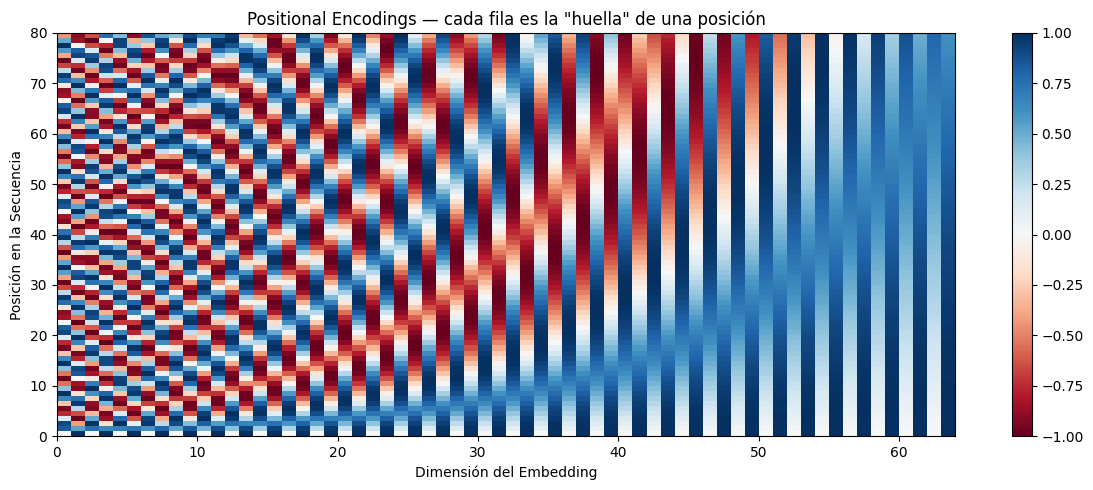

Observa el patrón sinusoidal: cada posición tiene una combinación única de valores


In [10]:
class SinusoidalPositionalEncoding(nn.Module):
    """Positional Encoding sinusoidal del paper 'Attention is All You Need'."""

    def __init__(self, max_len: int, d_model: int):
        super().__init__()
        # Vector columna de posiciones: [0, 1, 2, ..., max_len-1]
        pos = torch.arange(max_len).unsqueeze(1)          # (max_len, 1)
        # Vector fila de dimensiones: [0, 1, 2, ..., d_model-1]
        i = torch.arange(d_model).unsqueeze(0)            # (1, d_model)
        # Denominador de la fórmula
        div_term = 1 / torch.pow(10000, (2 * (i // 2)) / d_model)
        angles = pos * div_term                           # (max_len, d_model)
        # Seno en dimensiones pares, coseno en impares
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(angles[:, 0::2])
        pe[:, 1::2] = torch.cos(angles[:, 1::2])
        # Guardamos como buffer (no es un parámetro entrenable)
        self.register_buffer('pos_encoding', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        return x + self.pos_encoding[:, :x.size(1), :]


# Visualizamos los Positional Encodings
pe_viz = SinusoidalPositionalEncoding(max_len=256, d_model=128)
pe_matrix = pe_viz.pos_encoding.squeeze(0).numpy()

plt.figure(figsize=(12, 5))
plt.pcolormesh(pe_matrix[:80, :64], cmap='RdBu')
plt.xlabel('Dimensión del Embedding')
plt.ylabel('Posición en la Secuencia')
plt.title('Positional Encodings — cada fila es la "huella" de una posición')
plt.colorbar()
plt.tight_layout()
plt.show()
print('Observa el patrón sinusoidal: cada posición tiene una combinación única de valores')

### Token + Positional Embeddings

La capa que el modelo realmente usa combina dos cosas:
1. **Token Embedding**: convierte cada token ID en un vector de `d_model` dimensiones (se aprende durante entrenamiento)
2. **Positional Encoding**: le suma el vector de posición correspondiente

El resultado: cada token no solo sabe *qué* es, sino *dónde está* en la frase.

In [11]:
class TokenAndPositionalEmbedding(nn.Module):
    """Combina embeddings de tokens con positional encodings."""

    def __init__(self, max_len: int, d_model: int, vocab_size: int, dropout: float = 0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc   = SinusoidalPositionalEncoding(max_len, d_model)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x):
        # x shape: (batch, seq_len) — IDs de tokens
        emb = self.token_emb(x)   # (batch, seq_len, d_model)
        emb = self.pos_enc(emb)   # suma positional encoding
        return self.dropout(emb)


# Prueba rápida con un batch ficticio
vocab_size = tokenizer.vocab_size
d_model    = 128
tpe_test   = TokenAndPositionalEmbedding(MAX_SEQUENCE_LENGTH, d_model, vocab_size)
dummy_ids  = torch.randint(0, vocab_size, (2, MAX_SEQUENCE_LENGTH))  # batch=2
output     = tpe_test(dummy_ids)
print(f'Input shape:  {dummy_ids.shape}  (batch=2, seq_len={MAX_SEQUENCE_LENGTH})')
print(f'Output shape: {output.shape}  (batch=2, seq_len={MAX_SEQUENCE_LENGTH}, d_model={d_model})')
print('TokenAndPositionalEmbedding funciona correctamente')

Input shape:  torch.Size([2, 256])  (batch=2, seq_len=256)
Output shape: torch.Size([2, 256, 128])  (batch=2, seq_len=256, d_model=128)
TokenAndPositionalEmbedding funciona correctamente


## Paso 8 — Multi-Head Attention
Este es el componente central que diferencia a los Transformers de todas las arquitecturas anteriores. La atención responde la pregunta: *"Para entender el significado de esta palabra en este contexto, ¿en qué otras palabras del texto debo fijarme?"*

La operación fundamental es el **Scaled Dot-Product Attention**:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Donde **Q (Query)** representa la palabra que intenta entender su contexto, **K (Key)** representa todas las palabras que ofrecen información de contexto, y **V (Value)** contiene el contenido semántico que cada palabra aporta. La multiplicación Q·Kᵀ mide la afinidad entre cada par de palabras; el softmax normaliza esas afinidades en pesos de atención; y la multiplicación final por V produce un vector de contexto enriquecido.

**¿Por qué múltiples cabezas?**
En lugar de calcular una única atención, el modelo proyecta Q, K y V en `H` sub-espacios diferentes y calcula la atención en paralelo en cada uno. Cada cabeza aprende a especializarse en un tipo diferente de relación: una puede capturar dependencias sintácticas, otra co-referencias, otra relaciones semánticas temáticas. Los resultados se concatenan y proyectan de vuelta a `d_model`.

In [12]:
import math

class MultiHeadAttention(nn.Module):
    """Multi-Head Attention según 'Attention is All You Need' (Vaswani et al., 2017)."""

    def __init__(self, d_model: int, num_heads: int = 8):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model debe ser divisible por num_heads'

        self.d_model    = d_model
        self.num_heads  = num_heads
        self.d_k        = d_model // num_heads  # dimensión por cabeza

        # Proyecciones lineales para Q, K, V y la salida
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    @staticmethod
    def scaled_dot_product(q, k, v, mask=None):
        """Attention(Q,K,V) = softmax(QK^T / sqrt(d_k)) * V"""
        d_k = q.size(-1)
        # Puntuaciones de atención: cuánto se parece Q con cada K
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)  # (..., seq, seq)
        # Máscara de padding: ponemos -inf donde hay padding para que softmax → 0
        if mask is not None:
            mask_expanded = mask.unsqueeze(1).unsqueeze(2)  # (batch, 1, 1, seq)
            scores = scores.masked_fill(mask_expanded == 0, float('-inf'))
        # Softmax convierte scores en pesos de atención (suman 1)
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = torch.nan_to_num(attn_weights, nan=0.0)  # por si hay filas todo -inf
        # Promedio ponderado de los valores V
        return torch.matmul(attn_weights, v)

    def split_heads(self, x):
        """Divide d_model en num_heads cabezas para procesarlas en paralelo."""
        batch, seq_len, _ = x.size()
        x = x.view(batch, seq_len, self.num_heads, self.d_k)
        return x.transpose(1, 2)  # (batch, num_heads, seq_len, d_k)

    def forward(self, x, mask=None):
        # Proyectamos a Q, K, V y dividimos en cabezas
        Q = self.split_heads(self.W_q(x))
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))
        # Atención por cabeza en paralelo
        attended = self.scaled_dot_product(Q, K, V, mask)
        # Reunimos las cabezas y proyectamos a d_model
        batch, _, seq_len, _ = attended.size()
        attended = attended.transpose(1, 2).contiguous().view(batch, seq_len, self.d_model)
        return self.W_o(attended)


# Prueba
mha_test = MultiHeadAttention(d_model=128, num_heads=8)
dummy_emb = torch.randn(2, MAX_SEQUENCE_LENGTH, 128)
output = mha_test(dummy_emb)
print(f'Input shape:  {dummy_emb.shape}  (batch=2, seq_len={MAX_SEQUENCE_LENGTH}, d_model=128)')
print(f'Output shape: {output.shape}  (misma forma — la atención no cambia las dimensiones)')
print('Multi-Head Attention funciona correctamente')

Input shape:  torch.Size([2, 256, 128])  (batch=2, seq_len=256, d_model=128)
Output shape: torch.Size([2, 256, 128])  (misma forma — la atención no cambia las dimensiones)
Multi-Head Attention funciona correctamente


## Paso 9 — TransformerBlock (Encoder)
El bloque Transformer Encoder completo integra cuatro sub-componentes en secuencia:

1. **Multi-Head Attention**: Cada token atiende a todos los demás en paralelo, produciendo una representación enriquecida con contexto global.

2. **Add & Norm (primera)**: Se suma la entrada original al resultado de la atención (**conexión residual**) y se aplica Layer Normalization. Las conexiones residuales son fundamentales: permiten que el gradiente fluya directamente hacia capas anteriores sin desvanecerse, resolviendo el problema del *vanishing gradient* que limitaba las redes profundas.

3. **Feed-Forward Network**: Dos capas densas con activación ReLU que procesan cada posición de forma independiente. Expande la representación a `ff_dim` dimensiones y la comprime de vuelta a `d_model`, permitiendo al modelo aprender transformaciones no lineales complejas.

4. **Add & Norm (segunda)**: Una segunda conexión residual y normalización después de la FFN.

Este bloque preserva la forma del tensor de entrada `(batch, seq_len, d_model)`, por lo que múltiples bloques pueden apilarse para mayor profundidad.

In [13]:
class TransformerBlock(nn.Module):
    """Un bloque Transformer Encoder completo con atención, FFN y normalización."""

    def __init__(self, d_model: int, num_heads: int = 8, ff_dim: int = 512, dropout: float = 0.1):
        super().__init__()
        self.attention   = MultiHeadAttention(d_model, num_heads)
        self.attn_drop   = nn.Dropout(dropout)
        self.norm1       = nn.LayerNorm(d_model)

        # Feed-Forward Network: expande a ff_dim y vuelve a d_model
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model)
        )
        self.ffn_drop = nn.Dropout(dropout)
        self.norm2    = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        # Sub-capa 1: Multi-Head Attention + conexión residual
        attn_out = self.attention(x, mask)
        attn_out = self.attn_drop(attn_out)
        x = self.norm1(x + attn_out)        # Add & Norm

        # Sub-capa 2: Feed-Forward + conexión residual
        ffn_out = self.ffn(x)
        ffn_out = self.ffn_drop(ffn_out)
        x = self.norm2(x + ffn_out)         # Add & Norm

        return x


# Prueba
tb_test = TransformerBlock(d_model=128, num_heads=8)
output  = tb_test(dummy_emb)
print(f'Input shape:  {dummy_emb.shape}')
print(f'Output shape: {output.shape}  (el bloque preserva la forma)')
print('TransformerBlock funciona correctamente')

Input shape:  torch.Size([2, 256, 128])
Output shape: torch.Size([2, 256, 128])  (el bloque preserva la forma)
TransformerBlock funciona correctamente


## Paso 10 — Clasificador Transformer completo
Unimos todos los componentes en un pipeline de clasificación:

```
input_ids → TokenAndPositionalEmbedding → TransformerBlock → token [CLS] → Clasificador → categoría
```

**¿Qué es el token `[CLS]`?**
BERT popularizó la convención de insertar un token especial `[CLS]` (*Classification*) al inicio de cada secuencia. Al pasar por el bloque de atención, este token atiende a todas las palabras del abstract y acumula una representación del significado global del texto. La capa clasificadora usa exclusivamente este vector para predecir la categoría, evitando colapsar toda la secuencia con un promedio (como hacía GlobalAveragePooling en el Proyecto 2).

**PyTorch Lightning** estructura el entrenamiento en métodos semánticos claros: `training_step` para el loop de entrenamiento, `validation_step` para la evaluación por época, y `configure_optimizers` para definir el optimizador y el scheduler de learning rate.

In [14]:
class ArxivTransformerClassifier(LightningModule):
    """Clasificador de artículos arXiv usando un Transformer construido desde cero."""

    def __init__(self, vocab_size: int, num_classes: int, max_len: int,
                 d_model: int = 128, num_heads: int = 8,
                 ff_dim: int = 256, dropout: float = 0.1,
                 class_weights: torch.Tensor = None, lr: float = 1e-3):
        super().__init__()
        self.save_hyperparameters(ignore=['class_weights'])
        self.lr = lr

        # Arquitectura
        self.embedding   = TokenAndPositionalEmbedding(max_len, d_model, vocab_size, dropout)
        self.transformer = TransformerBlock(d_model, num_heads, ff_dim, dropout)
        self.classifier  = nn.Sequential(
            nn.Linear(d_model, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

        # Función de pérdida con class weights para manejar desbalance
        self.loss_fn = nn.CrossEntropyLoss(weight=class_weights)

        # Métricas
        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc   = Accuracy(task='multiclass', num_classes=num_classes)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)                    # (batch, seq, d_model)
        x = self.transformer(x, attention_mask)          # (batch, seq, d_model)
        cls_token = x[:, 0, :]                           # [CLS] token: (batch, d_model)
        return self.classifier(cls_token)                # (batch, num_classes)

    def training_step(self, batch, batch_idx):
        logits = self(batch['input_ids'], batch['attention_mask'])
        loss   = self.loss_fn(logits, batch['label'])
        preds  = torch.argmax(logits, dim=1)
        self.train_acc(preds, batch['label'])
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc',  self.train_acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        logits = self(batch['input_ids'], batch['attention_mask'])
        loss   = self.loss_fn(logits, batch['label'])
        preds  = torch.argmax(logits, dim=1)
        self.val_acc(preds, batch['label'])
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc',  self.val_acc, prog_bar=True)

    def predict_step(self, batch, batch_idx):
        return torch.argmax(self(batch['input_ids'], batch['attention_mask']), dim=1)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', patience=2, factor=0.5
        )
        return {'optimizer': optimizer,
                'lr_scheduler': {'scheduler': scheduler, 'monitor': 'val_loss'}}


print('ArxivTransformerClassifier definido')

ArxivTransformerClassifier definido


## Paso 11 — Class Weights y Configuración del Modelo
A pesar de haber filtrado el Top 10 de categorías, persiste un desbalance natural: `cs.LG` concentra más del doble de registros que `cs.CL` o `astro-ph.GA`. Si entrenamos sin corregir esto, el modelo aprenderá a favorecer las categorías mayoritarias para minimizar la pérdida de forma artificial, sin realmente aprender a distinguir las minoritarias.

**Estrategia implementada:**
Reutilizamos `compute_class_weight` de Scikit-Learn para asignar pesos inversamente proporcionales a la frecuencia de cada clase. Al pasar `class_weights` a la función de pérdida `CrossEntropyLoss`, cada error en una categoría minoritaria penaliza más al modelo que un error en una categoría mayoritaria, forzando un aprendizaje más equilibrado.

In [15]:
# Calcular class weights (misma estrategia del Proyecto 2)
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32)

print('Class weights calculados:')
for i, w in enumerate(class_weights_np):
    print(f'  {le.inverse_transform([i])[0]:<18} → peso: {w:.4f}')

Class weights calculados:
  astro-ph.GA        → peso: 1.3813
  cond-mat.mtrl-sci  → peso: 1.2007
  cs.CL              → peso: 1.4915
  cs.CV              → peso: 0.6897
  cs.LG              → peso: 0.4902
  hep-ph             → peso: 1.0684
  hep-th             → peso: 1.2706
  math.AP            → peso: 1.3960
  math.CO            → peso: 1.6207
  quant-ph           → peso: 0.8154


In [16]:
# Instanciamos el modelo
model = ArxivTransformerClassifier(
    vocab_size     = tokenizer.vocab_size,
    num_classes    = num_classes,
    max_len        = MAX_SEQUENCE_LENGTH,
    d_model        = 128,
    num_heads      = 8,
    ff_dim         = 256,
    dropout        = 0.1,
    class_weights  = class_weights_tensor,
    lr             = 1e-3
)

# Contamos parámetros entrenables
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Modelo listo')
print(f'Parámetros entrenables: {total_params:,}')

Modelo listo
Parámetros entrenables: 4,074,890


## Paso 12 — Entrenamiento con PyTorch Lightning
El `Trainer` de PyTorch Lightning automatiza el loop completo de entrenamiento: iteración sobre batches, cómputo del gradiente, actualización de pesos, evaluación por época y logging de métricas. Equivale al `.fit()` de Keras pero con mayor control sobre el proceso.

**Callbacks configurados:**

* **`EarlyStopping`** con `patience=5`: Detiene el entrenamiento si la pérdida de validación no mejora durante 5 épocas consecutivas, restaurando los mejores pesos encontrados. El valor de `patience=5` fue determinado experimentalmente: con `patience=3` el modelo detenía prematuramente su aprendizaje, perdiendo ~4 puntos de accuracy.

* **`ModelCheckpoint`**: Guarda automáticamente el checkpoint con mejor `val_acc` durante el entrenamiento, independientemente de cuándo ocurra el Early Stopping.

* **`ReduceLROnPlateau`**: Reduce el learning rate a la mitad si la pérdida de validación se estanca, permitiendo que el modelo refine sus pesos con pasos más pequeños.

In [17]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='min',
    verbose=True
)

checkpoint = ModelCheckpoint(
    monitor='val_acc',
    mode='max',
    save_top_k=1,
    filename='best-arxiv-transformer'
)

# Trainer
trainer = Trainer(
    max_epochs        = 15,
    accelerator       = 'auto',    # usa GPU si está disponible
    devices           = 1,
    callbacks         = [early_stop, checkpoint],
    enable_progress_bar = True,
    log_every_n_steps = 10
)

print('Iniciando entrenamiento...')
trainer.fit(model, train_loader, test_loader)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


Iniciando entrenamiento...


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name        | Type                        | Params
------------------------------------------------------------
0 | embedding   | TokenAndPositionalEmbedding | 3.9 M 
1 | transformer | TransformerBlock            | 132 K 
2 | classifier  | Sequential                  | 35.6 K
3 | loss_fn     | CrossEntropyLoss            | 0     
4 | train_acc   | MulticlassAccuracy          | 0     
5 | val_acc     | MulticlassAccuracy          | 0     
------------------------------------------------------------
4.1 M     Trainable params
0         Non-trainable params
4.1 M     Total params
16.300    Total estimated model params size (MB)
INFO:lightning.pytorch.callbacks.model_summary:
  | Name        | Type                        | Params
------------------------------------------------------------
0 | embedding   | TokenAndPositionalEmbedding | 3.9 M 
1 | tr

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric val_loss did not improve in the last 5 records. Best score: 0.598. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 5 records. Best score: 0.598. Signaling Trainer to stop.


## Paso 13 — Evaluación y Comparación Final
Evaluamos el modelo entrenado sobre el conjunto de test (20% del corpus, nunca visto durante el entrenamiento) y comparamos los resultados contra las tres arquitecturas implementadas en el Proyecto 2.

La comparación es directamente válida porque utilizamos exactamente el mismo corpus, el mismo preprocesamiento, el mismo split 80/20 estratificado y los mismos class weights. Cualquier diferencia en accuracy se atribuye exclusivamente a la arquitectura del modelo.

In [18]:
# Evaluación en el conjunto de test
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
all_preds  = []
all_labels = []

# Movemos el modelo a CPU para la evaluación si es necesario
eval_device = next(model.parameters()).device

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(eval_device)
        attention_mask = batch['attention_mask'].to(eval_device)
        labels = batch['label']

        logits = model(input_ids, attention_mask)
        preds  = torch.argmax(logits, dim=1).cpu()

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# Accuracy manual
transformer_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f'Accuracy en test: {transformer_acc:.4f} ({transformer_acc*100:.2f}%)')

Accuracy en test: 0.8167 (81.67%)


In [19]:
# Predicciones para reporte detallado
# model.eval()
# all_preds  = []
# all_labels = []

# with torch.no_grad():
#     for batch in test_loader:
#         logits = model(batch['input_ids'], batch['attention_mask'])
#         preds  = torch.argmax(logits, dim=1)
#         all_preds.extend(preds.cpu().numpy())
#         all_labels.extend(batch['label'].cpu().numpy())

print('\n Classification Report:')
print(classification_report(
    all_labels, all_preds,
    target_names=le.classes_
))


 Classification Report:
                   precision    recall  f1-score   support

      astro-ph.GA       0.93      0.97      0.95        95
cond-mat.mtrl-sci       0.91      0.86      0.89       109
            cs.CL       0.70      0.86      0.77        87
            cs.CV       0.82      0.71      0.76       190
            cs.LG       0.77      0.80      0.78       267
           hep-ph       0.93      0.76      0.84       122
           hep-th       0.70      0.74      0.72       103
          math.AP       0.81      0.94      0.87        94
          math.CO       0.85      0.86      0.86        81
         quant-ph       0.84      0.83      0.83       161

         accuracy                           0.82      1309
        macro avg       0.83      0.83      0.83      1309
     weighted avg       0.82      0.82      0.82      1309



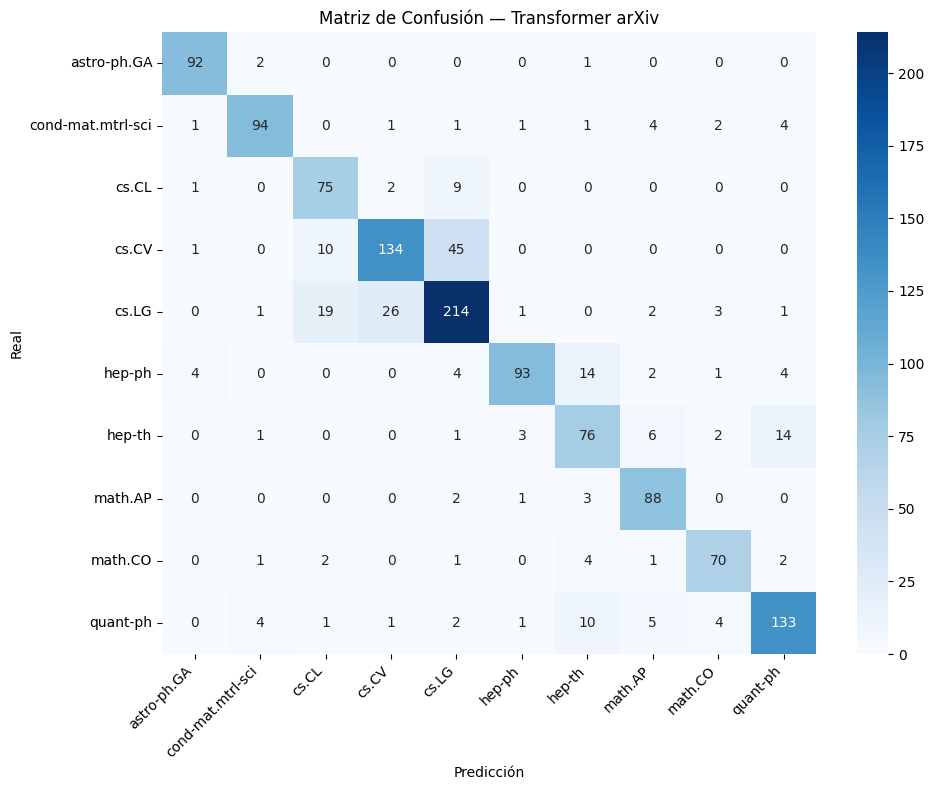

In [20]:
# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión — Transformer arXiv')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# TABLA COMPARATIVA — Proyecto 2 vs Proyecto 3
# ============================================================
transformer_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)

comparison = pd.DataFrame({
    'Modelo': [
        '1. Random Forest + TF-IDF',
        '2. Embeddings + GlobalAvgPooling',
        '3. LSTM (Keras)',
        '4. Transformer (este proyecto)'
    ],
    'Accuracy': [0.845, 0.90, 0.85, transformer_acc],
    'Framework': ['Scikit-Learn', 'Keras/TF', 'Keras/TF', 'PyTorch Lightning'],
    'Captura contexto': ['No', 'Parcial', 'Secuencial', 'Global (Attention)'],
    'Orden de palabras': ['No', 'No', 'Sí', 'Sí (Positional Enc.)']
})

comparison['Accuracy (%)'] = (comparison['Accuracy'] * 100).round(2)
print('\n COMPARACIÓN FINAL DE MODELOS')
print('=' * 70)
print(comparison[['Modelo', 'Accuracy (%)', 'Captura contexto', 'Orden de palabras']].to_string(index=False))
print('=' * 70)

best_model = comparison.loc[comparison['Accuracy'].idxmax(), 'Modelo']
print(f'\n Mejor modelo: {best_model}')


 COMPARACIÓN FINAL DE MODELOS
                          Modelo  Accuracy (%)   Captura contexto    Orden de palabras
       1. Random Forest + TF-IDF         84.50                 No                   No
2. Embeddings + GlobalAvgPooling         90.00            Parcial                   No
                 3. LSTM (Keras)         85.00         Secuencial                   Sí
  4. Transformer (este proyecto)         81.67 Global (Attention) Sí (Positional Enc.)

 Mejor modelo: 2. Embeddings + GlobalAvgPooling


Desempeño por categoría (ordenado por F1-score):


,Clase,precision,recall,f1-score,support
0,astro-ph.GA,0.929,0.968,0.948,95.000000
1,cond-mat.mtrl-sci,0.913,0.862,0.887,109.000000
7,math.AP,0.815,0.936,0.871,94.000000
8,math.CO,0.854,0.864,0.859,81.000000
5,hep-ph,0.930,0.762,0.838,122.000000
9,quant-ph,0.842,0.826,0.834,161.000000
4,cs.LG,0.767,0.801,0.784,267.000000
2,cs.CL,0.701,0.862,0.773,87.000000
3,cs.CV,0.817,0.705,0.757,190.000000
6,hep-th,0.697,0.738,0.717,103.000000


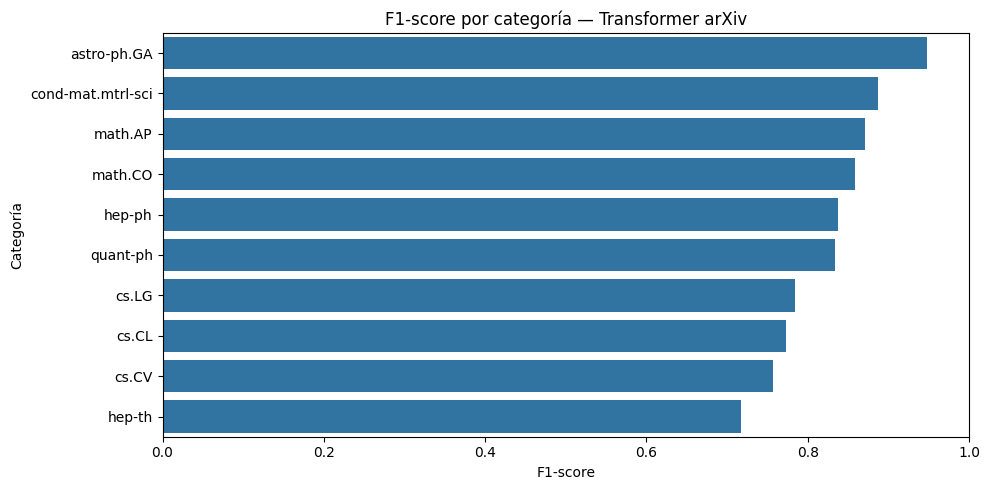

Mejor categoría según F1-score: astro-ph.GA (0.948)
Categoría más difícil según F1-score: hep-th (0.717)


In [22]:
# ============================================================
# ANÁLISIS DETALLADO POR CATEGORÍA
# ============================================================
report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=le.classes_,
    output_dict=True
)

report_df = (
    pd.DataFrame(report_dict)
    .transpose()
    .reset_index()
    .rename(columns={'index': 'Clase'})
)

# Conservamos solo las clases reales (sin accuracy/macro avg/weighted avg)
report_classes = report_df[report_df['Clase'].isin(le.classes_)].copy()
report_classes = report_classes[['Clase', 'precision', 'recall', 'f1-score', 'support']]
report_classes = report_classes.sort_values('f1-score', ascending=False)

print('Desempeño por categoría (ordenado por F1-score):')
display(report_classes.style.format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1-score': '{:.3f}'
}))

plt.figure(figsize=(10, 5))
sns.barplot(data=report_classes, x='f1-score', y='Clase')
plt.title('F1-score por categoría — Transformer arXiv')
plt.xlim(0, 1)
plt.xlabel('F1-score')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

best_class = report_classes.iloc[0]
worst_class = report_classes.iloc[-1]
print(f"Mejor categoría según F1-score: {best_class['Clase']} ({best_class['f1-score']:.3f})")
print(f"Categoría más difícil según F1-score: {worst_class['Clase']} ({worst_class['f1-score']:.3f})")

---
## Conclusiones Finales y Análisis del Equipo

Tras completar el pipeline de experimentación con una arquitectura **Transformer construida desde cero** sobre el corpus de **abstracts científicos de arXiv**, el resultado principal fue una **accuracy de 81.67%** en el conjunto de prueba. Aunque este valor quedó por debajo del mejor modelo del proyecto anterior (Embeddings + Global Average Pooling, ~90%), el experimento fue valioso porque permitió evaluar de forma directa el aporte de la **self-attention**, los **positional encodings** y una arquitectura más alineada con la teoría vista en clase.

### 1. Comparación global de modelos

La comparación con el Mini-Proyecto 2 muestra que no siempre una arquitectura más sofisticada supera automáticamente a modelos más simples. En este caso, el ranking final quedó así:

- **Embeddings + Global Average Pooling**: mejor desempeño global (~90%)
- **LSTM**: rendimiento intermedio (~85%)
- **Random Forest + TF-IDF**: baseline sólido (~84.5%)
- **Transformer from scratch**: **81.67%**

Este resultado sugiere que, para este dataset y con el presupuesto de entrenamiento usado, el Transformer aún no logra explotar todo su potencial, probablemente por limitaciones de tamaño de muestra, capacidad del modelo o profundidad de entrenamiento.

### 2. Análisis por categoría

El reporte de clasificación muestra comportamientos diferentes según el tipo de categoría:

- **Categorías con mejor desempeño**: `astro-ph.GA` alcanzó el mejor resultado (F1 ≈ 0.95), seguida de `cond-mat.mtrl-sci` y `math.AP`. Esto sugiere que estas áreas tienen vocabulario técnico más distintivo y menos ambigüedad semántica.
- **Categorías con desempeño intermedio**: `quant-ph`, `math.CO` y `hep-ph` mostraron resultados estables, con F1 cercanos o superiores a 0.83.
- **Categorías más difíciles**: `hep-th`, `cs.CV`, `cs.CL` y `cs.LG` fueron las más complejas. Esto es razonable porque varios abstracts de estas áreas comparten terminología matemática y computacional, lo que aumenta la confusión entre clases cercanas.

En particular, la posible cercanía entre categorías como **`cs.CL`**, **`cs.LG`** y **`cs.CV`** puede explicarse porque todas pertenecen al ecosistema de *computer science* y comparten términos como *model*, *training*, *representation*, *learning* o *neural*. El Transformer logra capturar relaciones globales entre palabras, pero aun así necesita más capacidad o mejor ajuste para separar con claridad dominios tan próximos.

### 3. ¿Por qué el Transformer obtuvo este resultado?

Hay varias razones técnicas que ayudan a interpretar el resultado:

1. **El modelo fue entrenado desde cero**, no usando pesos preentrenados tipo BERT. Eso significa que tuvo que aprender representaciones semánticas y patrones de atención únicamente a partir del dataset del proyecto.
2. **El corpus final es moderado** (Top 10 categorías después del filtrado), por lo que quizá no sea suficiente para que una arquitectura Transformer supere a enfoques más simples ya muy efectivos.
3. **La tokenización sí fue fuerte** gracias a `bert-base-uncased`, pero la arquitectura clasificadora no aprovechó conocimiento preentrenado del encoder, solo el vocabulario/tokenización.
4. **La tarea tiene categorías cercanas entre sí**, especialmente dentro de áreas científicas relacionadas, lo que exige mucha fineza semántica.

En resumen, el resultado no indica que el Transformer sea una mala opción, sino que **un Transformer pequeño y entrenado desde cero requiere más datos o más optimización para competir contra modelos simples bien ajustados**.

### 4. ¿Qué mejoraría el modelo?

Para una siguiente iteración, las mejoras más importantes serían:

- **Usar más capas Transformer** o aumentar `d_model` y `ff_dim` para elevar la capacidad representacional.
- **Entrenar durante más épocas** con una estrategia de *learning rate scheduling*.
- **Agregar validación separada explícita** y analizar con más detalle la curva de entrenamiento/validación.
- **Probar más regularización**: mayor dropout, label smoothing o weight decay.
- **Usar un modelo preentrenado completo** (por ejemplo, BERT fine-tuning) como comparación adicional. Esto permitiría medir cuánto aporta realmente el pretraining frente a un Transformer entrenado desde cero.
- **Analizar errores entre clases cercanas** con una inspección manual de abstracts mal clasificados.

### 5. Reflexión final

Este proyecto fue útil no solo para construir una solución de clasificación de texto, sino para entender mejor **qué aporta realmente la arquitectura Transformer** más allá del resultado numérico. A diferencia de los modelos del proyecto anterior, aquí se hizo explícita la lógica de los **positional encodings**, la **multi-head attention** y los **bloques encoder**, lo cual fortalece la comprensión conceptual del curso.

Además, el hecho de que el Transformer no haya sido el mejor modelo también es un hallazgo valioso: demuestra que en NLP no basta con elegir la arquitectura más moderna, sino que es necesario considerar el tamaño del dataset, el tipo de dominio, el preprocesamiento y el presupuesto de entrenamiento. Desde ese punto de vista, el experimento fue exitoso porque permitió comparar enfoques y extraer conclusiones metodológicas reales, no solo repetir el notebook guía.